In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load clean modeling dataset
df = pd.read_csv('gait_dataset_model.csv')

meta_cols    = ['subject', 'label', 'num_strides']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = df['label'].values

print("=== DATASET ===")
print(f"Subjects:    {len(df)}")
print(f"Features:    {len(feature_cols)}")
print(f"Parkinson's: {y.sum()}")
print(f"Healthy:     {(y==0).sum()}")

=== DATASET ===
Subjects:    31
Features:    25
Parkinson's: 15
Healthy:     16


In [3]:
print("\n=== USING LEAVE-ONE-OUT CROSS VALIDATION ===")
print("(Required for small datasets — tests each subject once)")
loo = LeaveOneOut()



=== USING LEAVE-ONE-OUT CROSS VALIDATION ===
(Required for small datasets — tests each subject once)


In [4]:
#  three models to compare
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            C=1.0,
            probability=True,
            random_state=42
        ))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1,
            max_iter=1000,
            random_state=42
        ))
    ]),
}


In [5]:
# Evaluate all three models
results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")

    # Get predictions for every subject
    y_pred      = cross_val_predict(model, X, y, cv=loo)
    y_pred_prob = cross_val_predict(model, X, y, cv=loo, method='predict_proba')[:, 1]

    # Compute metrics
    cm        = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)   # recall — catching real Parkinson's cases
    specificity = tn / (tn + fp)   # avoiding false alarms
    auc         = roc_auc_score(y, y_pred_prob)

    results[name] = {
        'accuracy':    accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'auc':         auc,
        'y_pred':      y_pred,
        'y_pred_prob': y_pred_prob,
        'cm':          cm,
    }

    print(f"  Accuracy:    {accuracy:.3f}")
    print(f"  Sensitivity: {sensitivity:.3f}  (Parkinson's correctly caught)")
    print(f"  Specificity: {specificity:.3f}  (Healthy correctly cleared)")
    print(f"  AUC-ROC:     {auc:.3f}")
    print(f"  Confusion matrix:")
    print(f"    TP={tp}  FN={fn}")
    print(f"    FP={fp}  TN={tn}")


Evaluating Random Forest...
  Accuracy:    0.839
  Sensitivity: 0.800  (Parkinson's correctly caught)
  Specificity: 0.875  (Healthy correctly cleared)
  AUC-ROC:     0.892
  Confusion matrix:
    TP=12  FN=3
    FP=2  TN=14

Evaluating SVM...
  Accuracy:    0.871
  Sensitivity: 0.733  (Parkinson's correctly caught)
  Specificity: 1.000  (Healthy correctly cleared)
  AUC-ROC:     0.871
  Confusion matrix:
    TP=11  FN=4
    FP=0  TN=16

Evaluating Logistic Regression...
  Accuracy:    0.871
  Sensitivity: 0.733  (Parkinson's correctly caught)
  Specificity: 1.000  (Healthy correctly cleared)
  AUC-ROC:     0.917
  Confusion matrix:
    TP=11  FN=4
    FP=0  TN=16


In [6]:
print("\n=== MODEL COMPARISON ===")
summary = pd.DataFrame({
    name: {
        'Accuracy':    f"{r['accuracy']:.3f}",
        'Sensitivity': f"{r['sensitivity']:.3f}",
        'Specificity': f"{r['specificity']:.3f}",
        'AUC-ROC':     f"{r['auc']:.3f}",
    }
    for name, r in results.items()
})
print(summary.to_string())

#  Pick best model by AUC
best_name = max(results, key=lambda n: results[n]['auc'])
best      = results[best_name]
print(f"\nBest model: {best_name} (AUC={best['auc']:.3f})")



=== MODEL COMPARISON ===
            Random Forest    SVM Logistic Regression
Accuracy            0.839  0.871               0.871
Sensitivity         0.800  0.733               0.733
Specificity         0.875  1.000               1.000
AUC-ROC             0.892  0.871               0.917

Best model: Logistic Regression (AUC=0.917)


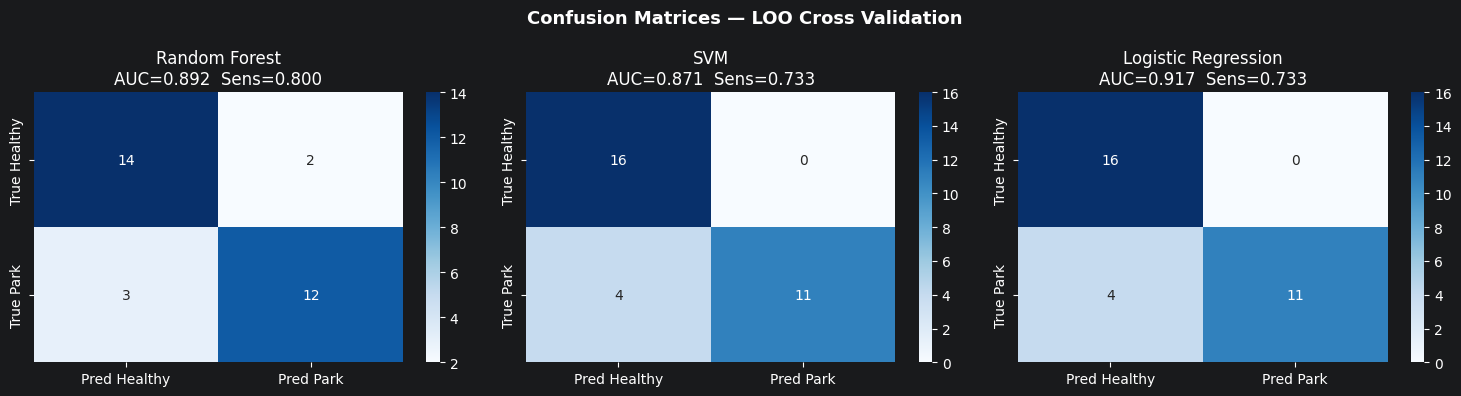

Saved model_plot1_confusion.png


In [7]:
# Plot 1: Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Healthy', 'Pred Park'],
                yticklabels=['True Healthy', 'True Park'],
                ax=ax)
    ax.set_title(f"{name}\nAUC={r['auc']:.3f}  Sens={r['sensitivity']:.3f}")
plt.suptitle('Confusion Matrices — LOO Cross Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_plot1_confusion.png', dpi=150)
plt.show()
print("Saved model_plot1_confusion.png")

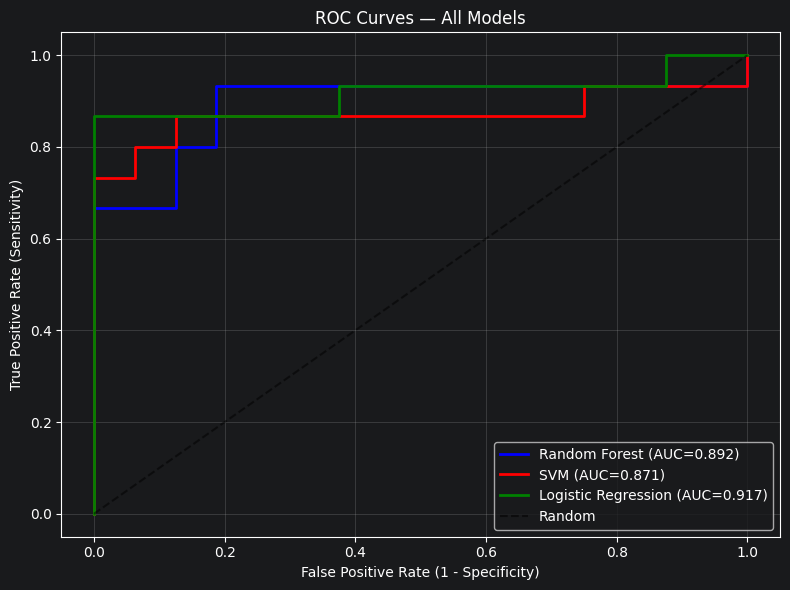

Saved model_plot2_roc.png


In [8]:
# Plot 2: ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y, r['y_pred_prob'])
    plt.plot(fpr, tpr, color=color,
             label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_plot2_roc.png', dpi=150)
plt.show()
print("Saved model_plot2_roc.png")

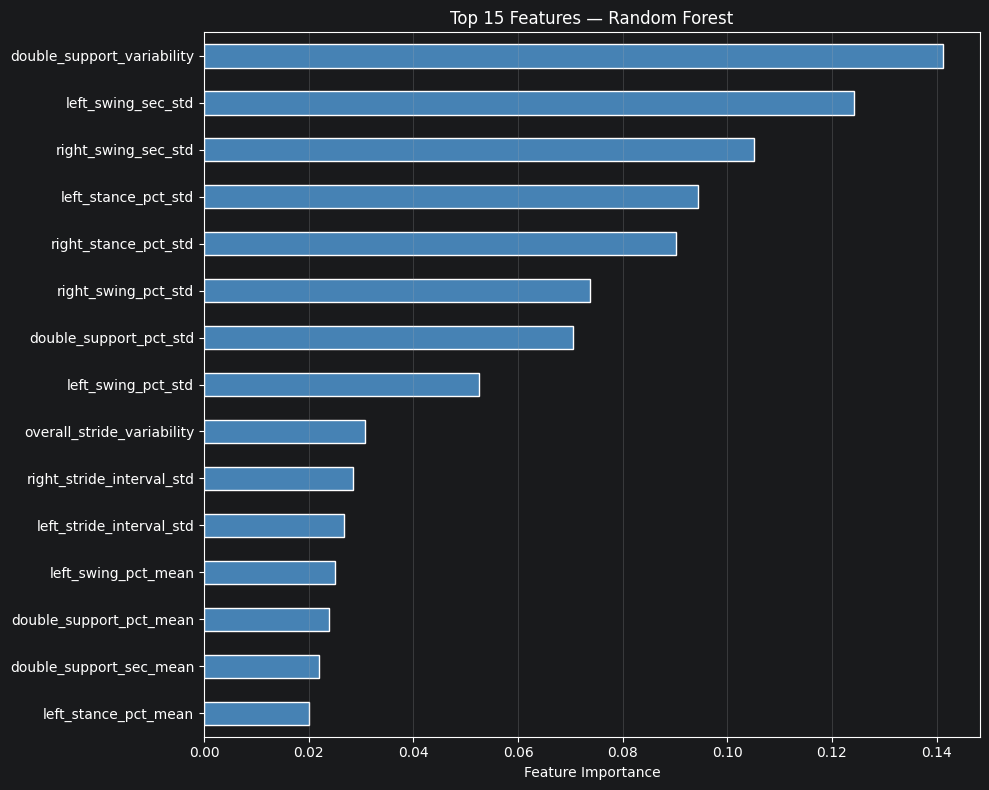

Saved model_plot3_feature_importance.png


In [9]:
#  Plot 3: Feature importance (Random Forest)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=4,
        min_samples_leaf=2, random_state=42
    ))
])
rf_pipeline.fit(X, y)
importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Top 15 Features — Random Forest')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_plot3_feature_importance.png', dpi=150)
plt.show()
print("Saved model_plot3_feature_importance.png")


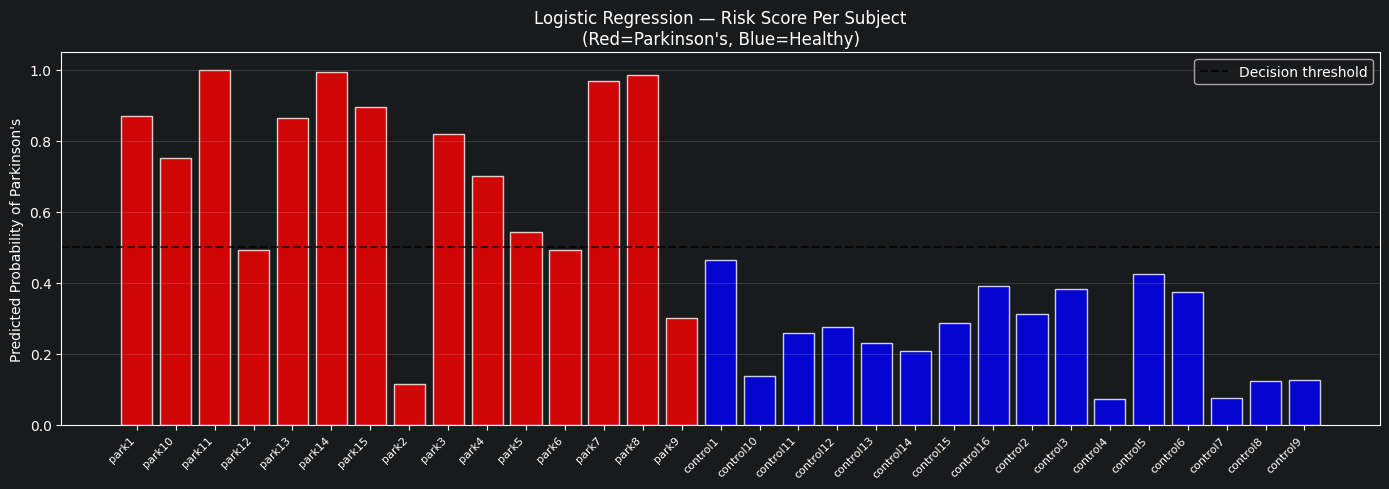

Saved model_plot4_risk_scores.png


In [10]:
# Plot 4: Predicted probability per subject
plt.figure(figsize=(14, 5))
subjects = df['subject'].values
colors_bar = ['red' if label == 1 else 'blue' for label in y]
plt.bar(subjects, best['y_pred_prob'], color=colors_bar, alpha=0.8, edgecolor='white')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Decision threshold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel(f'Predicted Probability of Parkinson\'s')
plt.title(f'{best_name} — Risk Score Per Subject\n(Red=Parkinson\'s, Blue=Healthy)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_plot4_risk_scores.png', dpi=150)
plt.show()
print("Saved model_plot4_risk_scores.png")

In [11]:
# Save the best model
best_pipeline = models[best_name]
best_pipeline.fit(X, y)
joblib.dump(best_pipeline, 'gaitsense_model.pkl')
joblib.dump(feature_cols,  'gaitsense_features.pkl')
print(f"\nSaved gaitsense_model.pkl")
print(f"Saved gaitsense_features.pkl")
print(f"\nTo load and use later:")
print(f"  model    = joblib.load('gaitsense_model.pkl')")
print(f"  features = joblib.load('gaitsense_features.pkl')")


Saved gaitsense_model.pkl
Saved gaitsense_features.pkl

To load and use later:
  model    = joblib.load('gaitsense_model.pkl')
  features = joblib.load('gaitsense_features.pkl')
